In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('yandex_eda_v1.csv')
df

,Unnamed: 0.4,Unnamed: 0,name,url,parsed_name,delivery_info,menu,reviews,Unnamed: 0.1,Unnamed: 0.2,Unnamed: 0.3
0,0,0,allo picca profsoyuznaya 140,https://eda.yandex.ru/restaurant/allo_picca_pr...,Алло! Пицца,Бесплатная доставка – для заказа от 600 ₽,"[{'title': 'Пицца Ветчина и сыр 23см', 'price'...",4.6 Закрыто (136 оценок До 11:00),NaN,NaN,NaN
1,1,1,pizzasushiwok ynguo,https://eda.yandex.ru/restaurant/pizzasushiwok...,PIZZASUSHIWOK,Бесплатная доставка – действует на заказ от 999₽,"[{'title': 'Запеченный ролл ""Калифорния""', 'pr...",4.6 65 – 75 мин (990 оценок Доставка ресторана),NaN,NaN,NaN
2,2,2,yakitoriya mh6s8,https://eda.yandex.ru/restaurant/yakitoriya_mh6s8,Якитория,Бесплатная доставка – для заказа от 600 ₽,"[{'title': 'Филадельфия Прайм', 'price': '919 ...",4.8 (308 оценок),NaN,NaN,NaN
3,3,3,siti c5nld,https://eda.yandex.ru/restaurant/siti_c5nld,Сити Пицца,NaN,"[{'title': 'Комбо Оазис', 'price': '1219 ₽', '...",— (—),NaN,NaN,NaN
4,4,4,zotman zvwod,https://eda.yandex.ru/restaurant/zotman_zvwod,Zotman Pizza,Бесплатная доставка – для заказа от 600 ₽,"[{'title': 'Баварская мясная', 'price': '810 ₽...",4.8 Закрыто (889 оценок До 12:00),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
238,1,234,sherif,https://eda.yandex.ru/restaurant/sherif,Яства,NaN,"[{'title': 'Бургер Классик', 'price': '-20% на...",— (—),218.0,203.0,193.0
239,2,235,terrasa ndfao,https://eda.yandex.ru/restaurant/terrasa_ndfao,Терраса,Бесплатная доставка – для заказа от 600 ₽,"[{'title': 'Кудряшка Сью', 'price': 'Бесплатна...",4.3 (8 оценок),219.0,204.0,194.0
240,3,236,kishpie wftsy,https://eda.yandex.ru/restaurant/kishpie_wftsy,Машенька,NaN,[{'title': 'Осетинский пирог с говяжьим фаршем...,— (—),220.0,205.0,195.0
241,4,237,schastlivaya konditerskaya tq7gl,https://eda.yandex.ru/restaurant/schastlivaya_...,Счастливая кондитерская,NaN,"[{'title': 'Бенто-Торт Единорог розовый', 'pri...",— (—),221.0,206.0,196.0


In [109]:
df = df[['parsed_name', 'delivery_info', 'menu', 'reviews']]

In [110]:
df = df[~df.menu.isna()]

In [111]:
import ast
def func(items):
    return ast.literal_eval(items)
df['menu'] = df.menu.apply(func)
df['menu']

0      [{'title': 'Пицца Ветчина и сыр 23см', 'price'...
1      [{'title': 'Запеченный ролл "Калифорния"', 'pr...
2      [{'title': 'Филадельфия Прайм', 'price': '919 ...
3      [{'title': 'Комбо Оазис', 'price': '1219 ₽', '...
4      [{'title': 'Баварская мясная', 'price': '810 ₽...
                             ...                        
238    [{'title': 'Бургер Классик', 'price': '-20% на...
239    [{'title': 'Кудряшка Сью', 'price': 'Бесплатна...
240    [{'title': 'Осетинский пирог с говяжьим фаршем...
241    [{'title': 'Бенто-Торт Единорог розовый', 'pri...
242    [{'title': 'Кутаб Сказка востока', 'price': '6...
Name: menu, Length: 236, dtype: object

In [112]:
def foo(items):
    result = []
    for item in items:
        if item['weight'] is not None and check_ruble_amount(item['price']) and check_g_unit(item['weight']):
            result.append(item)
    return result
df.menu = df.menu.apply(foo)

In [113]:
def foo2(items):
    result = []
    for item in items:
        try:
            w = parse_weight_to_grams(item['weight'])
        except:
            w = None
        result.append({'price': parse_price_to_kopecks(item['price']), 'weight':w, 'title':item['title']})
    return result
df.menu = df.menu.apply(foo2)

In [ ]:
def agg_avg(items):
    if len(items) == 0:
        return -1
    return sum(map(lambda x: x['price'], items)) / len(items)
df['avg_position_price'] = df.menu.apply(agg_avg)

In [118]:
# df.to_csv('clean.csv')
df = pd.read_csv('clean.csv', index_col='Unnamed: 0')

In [119]:
df

,parsed_name,delivery_info,menu,reviews,avg_position_price
0,Алло! Пицца,Бесплатная доставка – для заказа от 600 ₽,"[{'price': 359.0, 'weight': 325, 'title': 'Пиц...",4.6 Закрыто (136 оценок До 11:00),838.572519
1,PIZZASUSHIWOK,Бесплатная доставка – действует на заказ от 999₽,"[{'price': 459.0, 'weight': 182, 'title': 'Зап...",4.6 65 – 75 мин (990 оценок Доставка ресторана),732.819672
2,Якитория,Бесплатная доставка – для заказа от 600 ₽,"[{'price': 919.0, 'weight': 235, 'title': 'Фил...",4.8 (308 оценок),842.769784
3,Сити Пицца,NaN,"[{'price': 1219.0, 'weight': 1235, 'title': 'К...",— (—),889.819149
4,Zotman Pizza,Бесплатная доставка – для заказа от 600 ₽,"[{'price': 810.0, 'weight': 410, 'title': 'Бав...",4.8 Закрыто (889 оценок До 12:00),613.943662
...,...,...,...,...,...
238,Яства,NaN,"[{'price': 448.0, 'weight': 315, 'title': 'Бур...",— (—),675.536000
239,Терраса,Бесплатная доставка – для заказа от 600 ₽,"[{'price': 340.0, 'weight': 220, 'title': 'Куд...",4.3 (8 оценок),528.823529
240,Машенька,NaN,"[{'price': 1418.0, 'weight': 500, 'title': 'Ос...",— (—),1506.417582
241,Счастливая кондитерская,NaN,"[{'price': 2090.0, 'weight': 350, 'title': 'Бе...",— (—),2389.205714


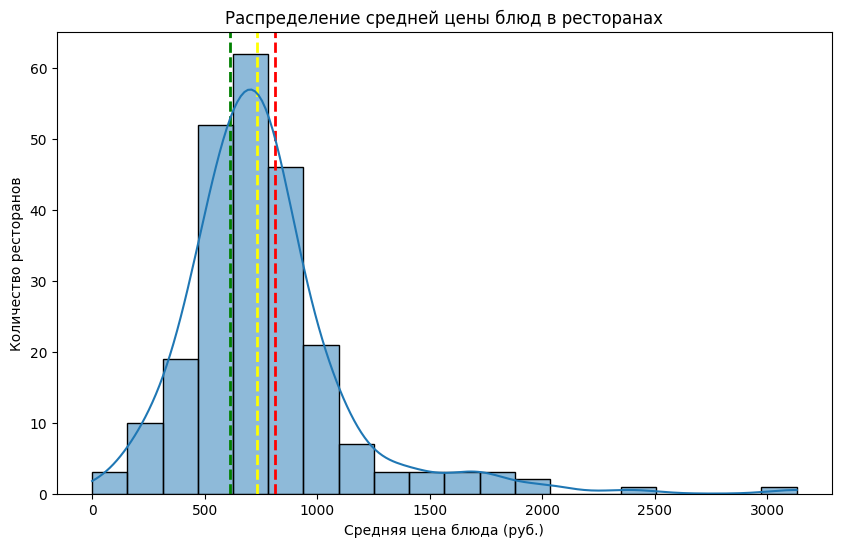

In [120]:
import seaborn as sns
plt.figure(figsize=(10,6))
pj_avg_price = df[df.parsed_name == 'Папа Джонс'].avg_position_price.mean()
zotman_avg_price = df[df.parsed_name.apply(lambda x: 'zotman' in x.lower())].avg_position_price.mean()


psw_avg_price = df[df.parsed_name.apply(lambda x: 'pizzasushi' in x.lower())].avg_position_price.mean()
plt.axvline(x=pj_avg_price, color='red', linestyle='--', linewidth=2)
plt.axvline(x=zotman_avg_price, color='green', linestyle='--', linewidth=2)
plt.axvline(x=psw_avg_price, color='yellow', linestyle='--', linewidth=2)

sns.histplot(df['avg_position_price'].dropna(), bins=20, kde=True)
plt.title('Распределение средней цены блюд в ресторанах')
plt.xlabel('Средняя цена блюда (руб.)')
plt.ylabel('Количество ресторанов')
plt.show()

In [121]:
import ast
import re
# df['pepperoni'] = df.menu.apply(lambda lst: list(filter(lambda x: x['title'].lower() in ['пепперони', 'пицца пепперони'] or re.match(r'пицца пепперони \d+\s*см', x['title'].lower()) or re.match(r'пепперони \d+\s*см', x['title'].lower(), re.IGNORECASE), ast.literal_eval(lst))))
df['pepperoni'] = df.menu.apply(lambda lst: list(filter(lambda x: 'пепперони' in x['title'].lower(), ast.literal_eval(lst))))


In [122]:
def agg_avg(items):
    if len(items) == 0:
        return -1
    return sum(map(lambda x: x['price'], items)) / len(items)
df['avg_pepperoni_price'] = df.pepperoni.apply(agg_avg)

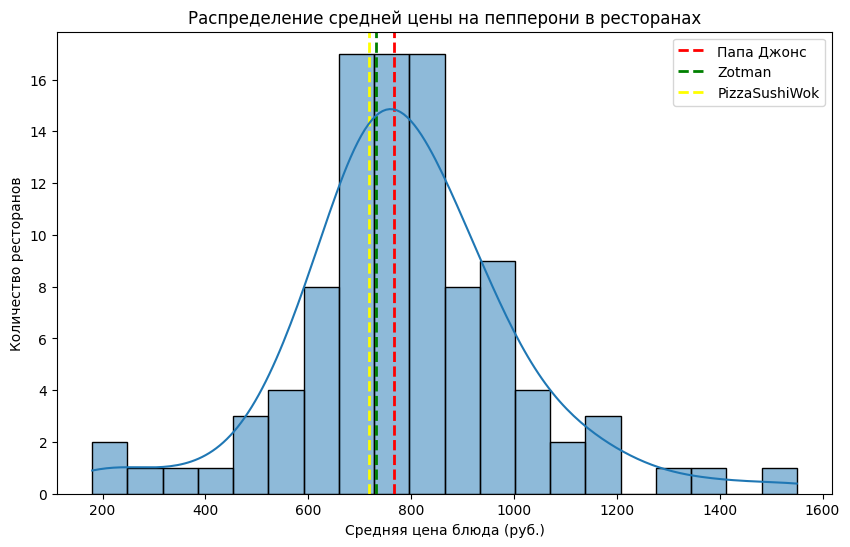

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

pj_avg_price = df[df.parsed_name == 'Папа Джонс'].avg_pepperoni_price.mean()
zotman_avg_price = df[df.parsed_name.apply(lambda x: 'zotman' in x.lower())].avg_pepperoni_price.mean()
psw_avg_price = df[df.parsed_name.apply(lambda x: 'pizzasushi' in x.lower())].avg_pepperoni_price.mean()

plt.axvline(x=pj_avg_price, color='red', linestyle='--', linewidth=2, label='Папа Джонс')
plt.axvline(x=zotman_avg_price, color='green', linestyle='--', linewidth=2, label='Zotman')
plt.axvline(x=psw_avg_price, color='yellow', linestyle='--', linewidth=2, label='PizzaSushiWok')

sns.histplot(df[df['avg_pepperoni_price'] > 0]['avg_pepperoni_price'].dropna(), bins=20, kde=True)

plt.title('Распределение средней цены на пепперони в ресторанах')
plt.xlabel('Средняя цена блюда (руб.)')
plt.ylabel('Количество ресторанов')
plt.legend()

plt.show()

In [124]:
def agg_avg(items):
    if len(items) == 0:
        return -1
    return sum(map(lambda x: x['price'] / x['weight'], items)) / len(items)
df['avg_pepperoni_pg_price'] = df.pepperoni.apply(agg_avg)

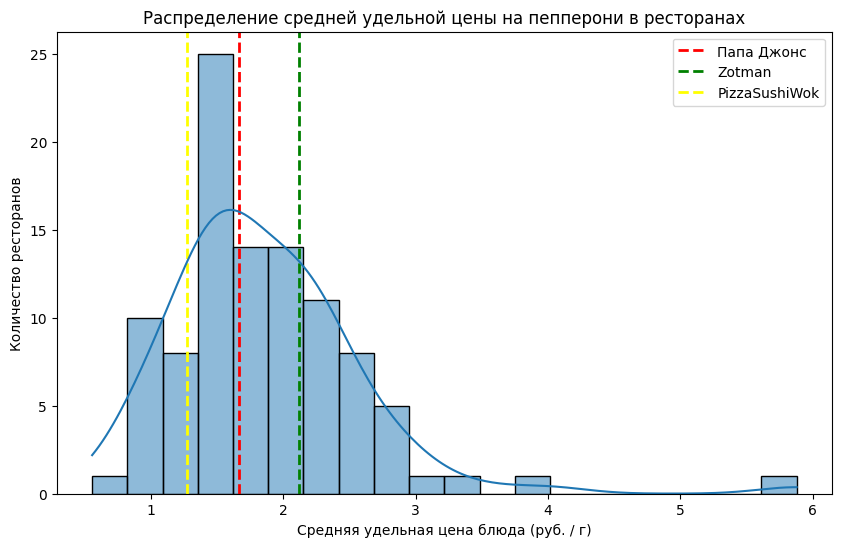

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

pj_avg_price = df[df.parsed_name == 'Папа Джонс'].avg_pepperoni_pg_price.mean()
zotman_avg_price = df[df.parsed_name.apply(lambda x: 'zotman' in x.lower())].avg_pepperoni_pg_price.mean()
psw_avg_price = df[df.parsed_name.apply(lambda x: 'pizzasushi' in x.lower())].avg_pepperoni_pg_price.mean()

plt.axvline(x=pj_avg_price, color='red', linestyle='--', linewidth=2, label='Папа Джонс')
plt.axvline(x=zotman_avg_price, color='green', linestyle='--', linewidth=2, label='Zotman')
plt.axvline(x=psw_avg_price, color='yellow', linestyle='--', linewidth=2, label='PizzaSushiWok')

sns.histplot(df[df['avg_pepperoni_pg_price'] > 0]['avg_pepperoni_pg_price'].dropna(), bins=20, kde=True)

plt.title('Распределение средней удельной цены на пепперони в ресторанах')
plt.xlabel('Средняя удельная цена блюда (руб. / г)')
plt.ylabel('Количество ресторанов')
plt.legend()

plt.show()

In [128]:
df['menu_len'] = df.menu.apply(lambda lst: len(ast.literal_eval(lst)))

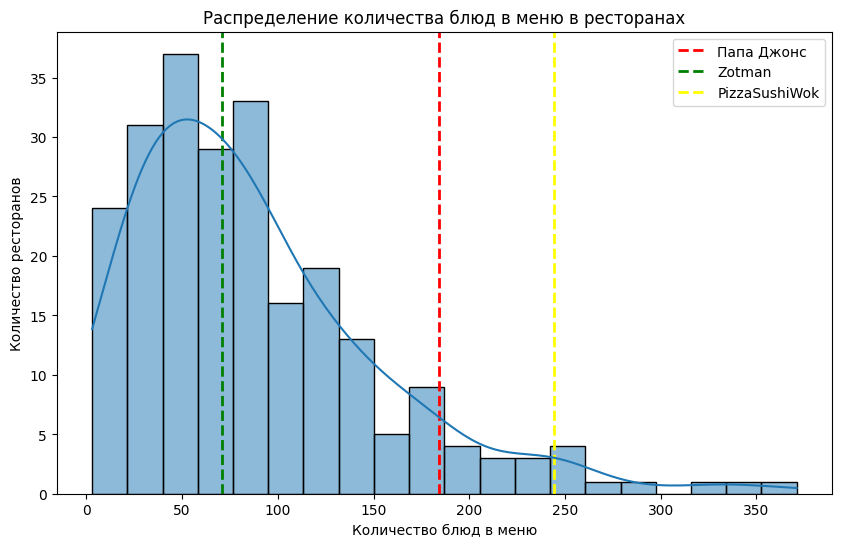

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

pj_len = df[df.parsed_name == 'Папа Джонс'].menu_len.mean()
zotman_len = df[df.parsed_name.apply(lambda x: 'zotman' in x.lower())].menu_len.mean()
psw_len = df[df.parsed_name.apply(lambda x: 'pizzasushi' in x.lower())].menu_len.mean()

plt.axvline(x=pj_len, color='red', linestyle='--', linewidth=2, label='Папа Джонс')
plt.axvline(x=zotman_len, color='green', linestyle='--', linewidth=2, label='Zotman')
plt.axvline(x=psw_len, color='yellow', linestyle='--', linewidth=2, label='PizzaSushiWok')

sns.histplot(df[df['menu_len'] > 0]['menu_len'].dropna(), bins=20, kde=True)

plt.title('Распределение количества блюд в меню в ресторанах')
plt.xlabel('Количество блюд в меню')
plt.ylabel('Количество ресторанов')
plt.legend()

plt.show()

In [31]:
print(set(x for x in excluded_r))

{',40 ₽', ',05 ₽', ',30 ₽', '–10% на всё – на всю корзину при заказе от 1051 ₽', ',85 ₽', ',25 ₽', ',60 ₽', ',80 ₽', 'Бесплатная доставка – для заказа от 600 ₽', '-20% на всё – при заказе от 1 ₽', ',10 ₽', ',20 ₽', '–10% на всё – на всю корзину при заказе от 2000 ₽', ',75 ₽', ',90 ₽', ',15 ₽', ',50 ₽'}
